# Avance 3. Baseline

## Proyecto Integrador - MNA

### Equipo 21

Integrantes del equipo:
- Guadalupe Esmeralda González Maldonado - A01795767
- Marco Daniel Cameros Bobadilla - A01795655
- Jesús Armando Anaya Orozco - A01795464

Nombre del dataset: DDR2019

## Contexto y objetivo de este notebook

Este notebook presenta un baseline para clasificación de retinopatía diabética a partir de imágenes de fondo de ojo.

Un baseline es la primera solución razonable y reproducible. Sirve como punto de comparación para decidir si conviene seguir iterando sobre el problema con evidencia.

En esta entrega se usa como enfoque principal **DenseNet-121** como extractor de características y **XGBoost** como clasificador. Se busca una solución práctica, estable y fácil de interpretar en tiempo de cómputo razonable.

### Cómo se cubren los criterios de evaluación

- **Algoritmo**: se justifica por tipo de dato (imágenes), costo de entrenamiento e interpretabilidad.
- **Características importantes**: XGBoost permite analizar relevancia de variables y entender qué señales influyen más.
- **Sub/sobreajuste**: se revisa desempeño por métricas y comportamiento por clase para detectar brechas de generalización.
- **Métrica de negocio**: se reportan métricas que consideran desbalance, no solo accuracy.
- **Desempeño mínimo**: el baseline debe superar una referencia ingenua para considerarse viable.

### Referencia de inspiración

La selección del baseline se guía por literatura reciente en detección de retinopatía diabética, en particular los trabajos *Identification of Diabetic Retinopathy Using Weighted Fusion Deep Learning Based on Dual-Channel Fundus Scans* y *Enhanced Detection of Diabetic Retinopathy Through Transfer Learning with DenseNet-121 and XGBoost Classifier*.


## 1) Setup del proyecto y dependencias

Esta sección define entorno, rutas y librerías para asegurar reproducibilidad. Es muy importante que la ejecución sea consistente entre corridas para comparar resultados de forma justa.

Se mantiene coherencia con Avance 2 en criterios de balanceo y transformaciones base. Esto conviene para no cambiar demasiadas variables al mismo tiempo.

Además, se separa el preprocesamiento por backbone porque cada arquitectura espera formatos de entrada específicos (tamaño y normalización). Así se busca evitar sesgos por incompatibilidad en la preparación de datos.


In [1]:
import os
import random
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
)
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from torchvision.models import DenseNet121_Weights
from torchvision.transforms import functional as TF
from torchvision.transforms.functional import InterpolationMode
from tqdm.auto import tqdm

from sam_ml.datasets import DDR2019Dataset

In [2]:
# Resolver la raíz del proyecto de forma robusta.
_path = Path.cwd()
while _path != _path.parent and not (_path / "pyproject.toml").exists():
    _path = _path.parent
PROJECT_ROOT = _path if (_path / "pyproject.toml").exists() else Path.cwd()
os.chdir(PROJECT_ROOT)

# Fijar semillas para reproducibilidad.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Dataset base para la baseline (baseline).
DATA_DIR = PROJECT_ROOT / "data" / "processed" / "ddr2019"
LABELS_CSV = DATA_DIR / "labels.csv"

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"DATA_DIR (baseline): {DATA_DIR}")
print(f"labels.csv existe: {LABELS_CSV.exists()}")


PROJECT_ROOT: /home/anaya/Development/Robomous/sam-ai
DATA_DIR (baseline): /home/anaya/Development/Robomous/sam-ai/data/processed/ddr2019
labels.csv existe: True


In [3]:
# Cargar dataset base (una sola imagen por muestra) y validar contrato de salida.
base_dataset_train = DDR2019Dataset(
    data_dir=DATA_DIR,
    split="train",
    train_ratio=0.8,
    val_ratio=0.2,
    transform=transforms.ToTensor(),
    random_state=SEED,
)

base_dataset_all = DDR2019Dataset(
    data_dir=DATA_DIR,
    split="all",
    transform=transforms.ToTensor(),
    random_state=SEED,
)

image_sample, label_sample = base_dataset_train[0]

print(f"Muestras train: {len(base_dataset_train)}")
print(f"Muestras all: {len(base_dataset_all)}")
print(f"Shape imagen: {tuple(image_sample.shape)}")
print(f"Label de ejemplo: {label_sample}")


Muestras train: 10015
Muestras all: 12522
Shape imagen: (3, 512, 512)
Label de ejemplo: 0


## 2) Configuración de preprocesamiento para el baseline

En esta primera parte solo se prepara lo necesario para el baseline con DenseNet-121.

Muy importante: se usa la normalización esperada por el modelo preentrenado para reducir desajustes entre la distribución de entrada y los pesos aprendidos en ImageNet.

En términos simples, el "input size esperado" es el tamaño de imagen para el que la red fue entrenada originalmente. Mantener ese tamaño y esa normalización ayuda a sostener un comportamiento estable.


In [4]:
# Definir pesos de referencia para el baseline.
densenet_weights = DenseNet121_Weights.DEFAULT
densenet_preset = densenet_weights.transforms()

densenet_norm_mean = torch.tensor(densenet_preset.mean, dtype=torch.float32)
densenet_norm_std = torch.tensor(densenet_preset.std, dtype=torch.float32)

print("Normalización del baseline (DenseNet-121):")
print(f"  input_size esperado: {densenet_preset.crop_size[0]} x {densenet_preset.crop_size[0]}")
print(f"  mean: {densenet_norm_mean.tolist()}")
print(f"  std: {densenet_norm_std.tolist()}")


Normalización del baseline (DenseNet-121):
  input_size esperado: 224 x 224
  mean: [0.48500001430511475, 0.4560000002384186, 0.4059999883174896]
  std: [0.2290000021457672, 0.2240000069141388, 0.22499999403953552]


## 3) Transformaciones de normalización del baseline

Se aplica normalización compatible con DenseNet-121 usando estadísticas de ImageNet.

Estas transformaciones preparan la imagen para que el backbone "vea" los datos en condiciones similares a su preentrenamiento. Eso reduce el riesgo de degradación por cambio de escala o distribución.

Conviene mantener la lógica de augmentación y balanceo coherente con Avance 2 para no mezclar demasiados cambios metodológicos al mismo tiempo.


In [5]:
def normalize_with_stats_torch(x: torch.Tensor, mean: torch.Tensor, std: torch.Tensor) -> torch.Tensor:
    """Normalizar tensor RGB con media/desviación esperadas por un backbone."""
    m = mean.view(3, 1, 1).to(x.device, x.dtype)
    s = std.view(3, 1, 1).to(x.device, x.dtype).clamp_min(1e-8)
    return (x - m) / s


def denormalize_with_stats_torch(x: torch.Tensor, mean: torch.Tensor, std: torch.Tensor) -> torch.Tensor:
    """Deshacer normalización RGB para visualización."""
    m = mean.view(3, 1, 1).to(x.device, x.dtype)
    s = std.view(3, 1, 1).to(x.device, x.dtype)
    return x * s + m


def preprocess_image_for_densenet(x: torch.Tensor) -> torch.Tensor:
    """Preprocesar imagen para baseline con DenseNet-121."""
    x = x.float().clamp(0.0, 1.0)
    return normalize_with_stats_torch(x, densenet_norm_mean, densenet_norm_std)


## 4) Balanceo de clases

En retinopatía diabética existe desbalance de clases. Si se entrena sin control, el modelo puede favorecer clases mayoritarias y fallar en clases menos frecuentes.

Criterios operativos:

- **Minoritarias**: `count < mean_count * 0.5`.
- **Aumento de exposición**: `AUGMENTATION_MULTIPLIER = 5` (original + HFlip + VFlip + Rot1 + Rot2).
- **Control de dominancia mayoritaria**: downsampling con `MAJORITY_CAP = 3500` si `count > mean_count` y `count > MAJORITY_CAP`.

Conexión con rúbrica: este punto justifica por qué macro-F1 y macro-recall son muy importantes. En escenarios desbalanceados, accuracy puede verse bien y aun así ocultar mal desempeño en clases minoritarias.

**Costo/beneficio**: balancear mejora cobertura entre clases y suele hacer más justa la evaluación, pero incrementa costo de cómputo por el volumen de muestras aumentadas.


In [6]:
train_rows = base_dataset_train._rows.reset_index(drop=True).copy()

class_counts = train_rows["label"].value_counts().sort_index()
mean_count = class_counts.mean()
minority_threshold = mean_count * 0.5
minority_classes = set(class_counts[class_counts < minority_threshold].index.tolist())

AUGMENTATION_MULTIPLIER = 5
MAJORITY_CAP = 3500

augmentation_targets: dict[int, dict[str, float]] = {}
for label, count in class_counts.items():
    is_minority = int(label) in minority_classes
    target_count = int(count) * AUGMENTATION_MULTIPLIER if is_minority else int(count)
    augmentation_targets[int(label)] = {
        "current_count": int(count),
        "target_count": int(target_count),
        "multiplier": AUGMENTATION_MULTIPLIER if is_minority else 1,
        "is_minority": is_minority,
    }

downsampling_ratios: dict[int, dict[str, float]] = {}
for label, count in class_counts.items():
    is_majority = float(count) > float(mean_count)
    if is_majority and int(count) > MAJORITY_CAP:
        new_count = MAJORITY_CAP
        reduction_pct = (1.0 - (new_count / int(count))) * 100.0
    else:
        new_count = int(count)
        reduction_pct = 0.0
    downsampling_ratios[int(label)] = {
        "current_count": int(count),
        "new_count": int(new_count),
        "reduction_pct": float(reduction_pct),
        "is_downsampled": bool(is_majority and int(count) > MAJORITY_CAP),
    }

final_counts: dict[int, int] = {}
for label in sorted(class_counts.index.tolist()):
    if int(label) in minority_classes:
        final_counts[int(label)] = int(augmentation_targets[int(label)]["target_count"])
    else:
        final_counts[int(label)] = int(downsampling_ratios[int(label)]["new_count"])

original_imbalance_ratio = float(class_counts.max() / class_counts.min())
final_counts_series = pd.Series(final_counts).sort_index()
final_imbalance_ratio = float(final_counts_series.max() / final_counts_series.min())

print("Resumen de balanceo (baseline):")
print(f"  class_counts: {class_counts.to_dict()}")
print(f"  mean_count: {mean_count:.2f}")
print(f"  minority_threshold (50% mean): {minority_threshold:.2f}")
print(f"  minority_classes: {sorted(list(minority_classes))}")
print(f"  AUGMENTATION_MULTIPLIER: {AUGMENTATION_MULTIPLIER}")
print(f"  MAJORITY_CAP: {MAJORITY_CAP}")
print(f"  ratio original: {original_imbalance_ratio:.2f}:1")
print(f"  ratio final: {final_imbalance_ratio:.2f}:1")


Resumen de balanceo (baseline):
  class_counts: {0: 5012, 1: 504, 2: 3581, 3: 188, 4: 730}
  mean_count: 2003.00
  minority_threshold (50% mean): 1001.50
  minority_classes: [1, 3, 4]
  AUGMENTATION_MULTIPLIER: 5
  MAJORITY_CAP: 3500
  ratio original: 26.66:1
  ratio final: 3.88:1


## 5) Utilidades de balanceo y augmentación

Estas utilidades concentran la lógica de muestreo por clase y de augmentación geométrica reproducible.

La idea es mantener reglas consistentes de balanceo para aumentar exposición de clases minoritarias y reducir dominancia de clases mayoritarias, sin alterar el flujo principal del baseline.


In [9]:
def _sample_indices_per_class(
    rows: pd.DataFrame,
    majority_cap: int,
    seed: int,
) -> list[int]:
    """Aplicar downsampling por clase para mayoritarias y mantener el resto."""
    rng = np.random.default_rng(seed)
    selected: list[int] = []

    counts = rows["label"].value_counts().sort_index()
    mean_count_local = counts.mean()

    for label in sorted(counts.index.tolist()):
        cls_rows = rows[rows["label"] == label]
        cls_indices = cls_rows.index.to_numpy()
        is_majority = counts[label] > mean_count_local

        if is_majority and len(cls_indices) > majority_cap:
            chosen = rng.choice(cls_indices, size=majority_cap, replace=False)
            selected.extend(chosen.tolist())
        else:
            selected.extend(cls_indices.tolist())

    return selected


def _build_augmented_sample_list(
    rows: pd.DataFrame,
    selected_indices: list[int],
    minority_set: set[int],
) -> list[tuple[int, int]]:
    """Construir lista (base_index, aug_id) según clase minoritaria/no minoritaria."""
    samples: list[tuple[int, int]] = []
    for idx in selected_indices:
        label = int(rows.loc[idx, "label"])
        if label in minority_set:
            # 0 = original, 1 = hflip, 2 = vflip, 3 = rot1, 4 = rot2
            for aug_id in (0, 1, 2, 3, 4):
                samples.append((int(idx), int(aug_id)))
        else:
            samples.append((int(idx), 0))
    return samples


def _draw_rotation_angles(rng: np.random.Generator) -> tuple[float, float]:
    """Generar dos ángulos distintos con magnitud en [10,15]."""

    def _one_angle() -> float:
        mag = float(rng.uniform(10.0, 15.0))
        sign = -1.0 if rng.random() < 0.5 else 1.0
        return sign * mag

    angle1 = _one_angle()
    angle2 = _one_angle()
    while abs(angle2 - angle1) < 1e-6:
        angle2 = _one_angle()
    return angle1, angle2



## 6) Verificación inicial del pipeline

Este bloque valida integridad básica del flujo antes de entrenar:

- formato y dimensiones esperadas de tensores,
- etiquetas en rango válido,
- consistencia entre tamaño del batch y contenido.

Esta verificación es muy importante para detectar errores tempranos de datos y evitar diagnósticos confusos durante el entrenamiento.


In [10]:
# Verificación rápida del dataset base (baseline).
batch_size = 8
baseline_loader = DataLoader(
    base_dataset_train,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
)

images_batch, labels_batch = next(iter(baseline_loader))

print("Sanity check:")
print(f"  images_batch shape: {tuple(images_batch.shape)}")
print(f"  labels_batch shape: {tuple(labels_batch.shape)}")
print(f"  rango imágenes: [{float(images_batch.min()):.3f}, {float(images_batch.max()):.3f}]")


Sanity check:
  images_batch shape: (8, 3, 512, 512)
  labels_batch shape: (8,)
  rango imágenes: [0.000, 1.000]


=== Resumen de pipeline ===
DATA_DIR: /home/anaya/Development/Robomous/sam-ai/data/processed/ddr2019
Split train base: 10015
Split all base: 12522
images_batch shape: (8, 3, 512, 512)
labels_batch shape: (8,)
Distribución original (train): {0: 5012, 1: 504, 2: 3581, 3: 188, 4: 730}
Distribución final objetivo: {0: 3500, 1: 2520, 2: 3500, 3: 940, 4: 3650}
Ratio original: 26.66:1
Ratio final: 3.88:1


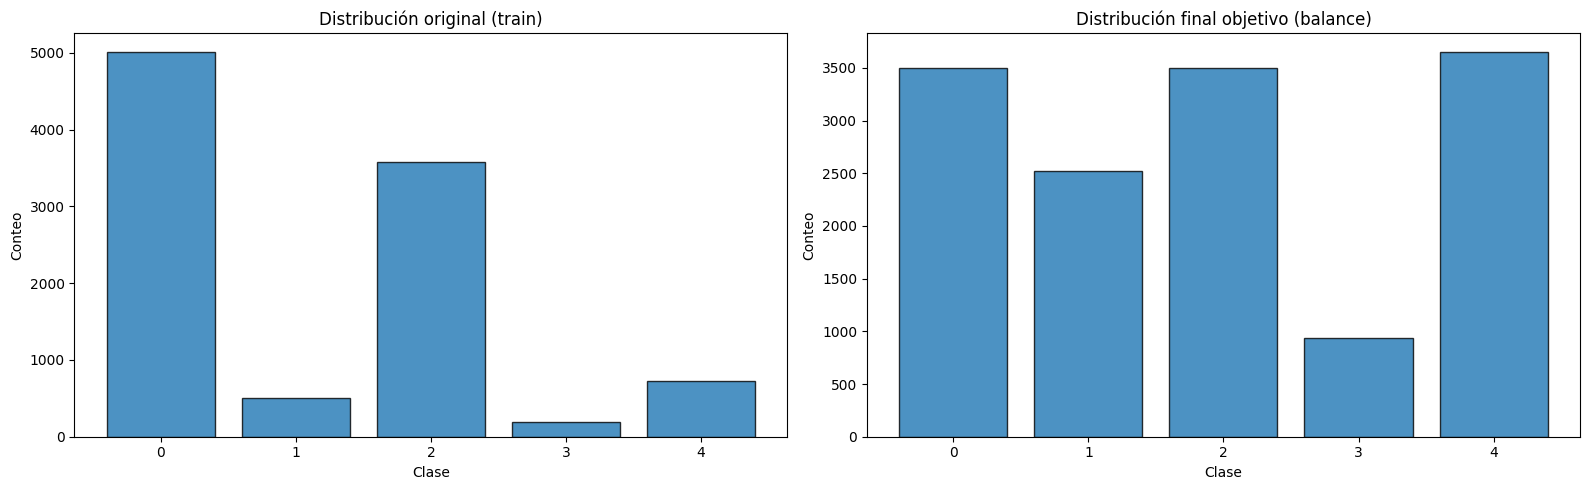

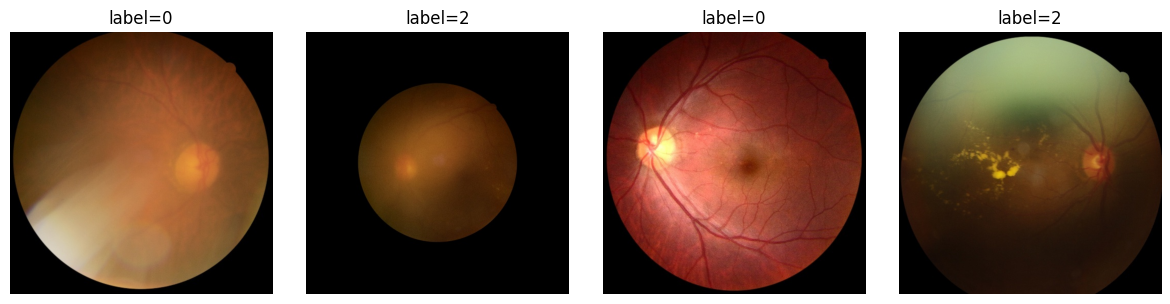

In [11]:
print("=== Resumen de pipeline ===")
print(f"DATA_DIR: {DATA_DIR}")
print(f"Split train base: {len(base_dataset_train)}")
print(f"Split all base: {len(base_dataset_all)}")
print(f"images_batch shape: {tuple(images_batch.shape)}")
print(f"labels_batch shape: {tuple(labels_batch.shape)}")
print(f"Distribución original (train): {class_counts.to_dict()}")
print(f"Distribución final objetivo: {final_counts_series.to_dict()}")
print(f"Ratio original: {original_imbalance_ratio:.2f}:1")
print(f"Ratio final: {final_imbalance_ratio:.2f}:1")

# Graficar distribución original vs final objetivo.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

classes_sorted = sorted(class_counts.index.tolist())
x = np.arange(len(classes_sorted))
orig_values = [int(class_counts.loc[c]) for c in classes_sorted]
final_values = [int(final_counts_series.loc[c]) for c in classes_sorted]

axes[0].bar(x, orig_values, edgecolor="black", alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(classes_sorted)
axes[0].set_title("Distribución original (train)")
axes[0].set_xlabel("Clase")
axes[0].set_ylabel("Conteo")

axes[1].bar(x, final_values, edgecolor="black", alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(classes_sorted)
axes[1].set_title("Distribución final objetivo (balance)")
axes[1].set_xlabel("Clase")
axes[1].set_ylabel("Conteo")

plt.tight_layout()
plt.show()

# Mostrar muestras del batch de la baseline.
n_show = min(4, images_batch.shape[0])
fig, axes = plt.subplots(1, n_show, figsize=(3 * n_show, 3))
if n_show == 1:
    axes = np.array([axes])

for i in range(n_show):
    image_vis = images_batch[i].detach().cpu().clamp(0.0, 1.0)
    axes[i].imshow(np.transpose(image_vis.numpy(), (1, 2, 0)))
    axes[i].set_title(f"label={int(labels_batch[i])}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## 7) Baseline (DenseNet-121 como extractor + XGBoost)

### A) Por qué este es nuestro baseline

Conviene porque trabaja bien con imágenes y permite construir una referencia sólida con costo de entrenamiento controlado.

- **DenseNet-121 preentrenado (extractor)**: reutiliza representación visual robusta y reduce costo de entrenamiento.
- **XGBoost (clasificador)**: entrena rápido, es estable y vale la pena porque permite analizar importancia de características.

### B) Qué significa "características" en este baseline

Se combinan dos tipos de señal:

- **Características profundas** (embeddings) obtenidas por DenseNet-121.
- **Características globales simples** calculadas sobre la imagen para aportar contexto complementario.

Muy importante: incluir variables irrelevantes puede introducir ruido y reducir generalización.

### C) Relevancia de características

XGBoost incorpora análisis de importancia de forma embebida. Esto permite interpretar qué componentes aportan más a la decisión y revisar si el modelo depende demasiado de un subconjunto pequeño.

### D) Regla de desempeño mínimo

**El baseline debe superar claramente un predictor ingenuo que siempre predice la clase mayoritaria.**

Si no lo supera, conviene revisar calidad de señal de datos y consistencia del pipeline antes de incrementar complejidad.


In [12]:
def _imagenet_stats_from_densenet() -> tuple[list[float], list[float]]:
    weights = DenseNet121_Weights.DEFAULT
    mean = list(weights.meta.get("mean", (0.485, 0.456, 0.406)))
    std = list(weights.meta.get("std", (0.229, 0.224, 0.225)))
    return mean, std


def _to_gray(x: torch.Tensor) -> torch.Tensor:
    """Convertir RGB->grayscale (tensor CHW en [0,1])."""
    r, g, b = x[0], x[1], x[2]
    return (0.2989 * r + 0.5870 * g + 0.1140 * b).clamp(0.0, 1.0)


def _global_features(x: torch.Tensor, hist_bins: int = 16) -> torch.Tensor:
    """Features globales: mean/std por canal + histograma en escala de grises."""
    ch_mean = x.mean(dim=(1, 2))
    ch_std = x.std(dim=(1, 2), unbiased=False)

    gray = _to_gray(x)
    hist = torch.histc(gray, bins=int(hist_bins), min=0.0, max=1.0)
    hist = hist / (hist.sum().clamp_min(1.0))

    return torch.cat([ch_mean, ch_std, hist], dim=0).float()


def _apply_geometry(
    image: torch.Tensor,
    aug_id: int,
    idx: int,
    seed: int,
) -> torch.Tensor:
    """Aplicar augmentación geométrica simple (reproducible por índice)."""
    if int(aug_id) == 0:
        return image
    if int(aug_id) == 1:
        return TF.hflip(image)
    if int(aug_id) == 2:
        return TF.vflip(image)

    rng = np.random.default_rng(int(seed) + int(idx))

    def _one_angle() -> float:
        mag = float(rng.uniform(10.0, 15.0))
        sign = -1.0 if rng.random() < 0.5 else 1.0
        return sign * mag

    angle1 = _one_angle()
    angle2 = _one_angle()
    while abs(angle2 - angle1) < 1e-6:
        angle2 = _one_angle()

    angle = angle1 if int(aug_id) == 3 else angle2
    return TF.rotate(
        image,
        angle=float(angle),
        interpolation=InterpolationMode.BILINEAR,
        fill=0.0,
    )


class BaselineSingleFeatureDataset(Dataset):
    """Dataset para baseline (ddr2019): imagen procesada para DenseNet + features globales extra."""

    def __init__(
        self,
        base_dataset: "DDR2019Dataset",
        samples: list[tuple[int, int]],
        seed: int,
        image_size: int = 224,
        hist_bins: int = 16,
    ) -> None:
        self.base_dataset = base_dataset
        self.samples = list(samples)
        self.seed = int(seed)
        self.image_size = int(image_size)
        self.hist_bins = int(hist_bins)

        self.mean, self.std = _imagenet_stats_from_densenet()

    def __len__(self) -> int:
        return len(self.samples)

    def _prep_for_densenet(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        # Redimensionar a 224x224 (para features globales consistentes) antes de normalizar.
        x = TF.resize(
            x,
            [self.image_size, self.image_size],
            interpolation=InterpolationMode.BILINEAR,
            antialias=True,
        )
        x = x.float().clamp(0.0, 1.0)

        extra = _global_features(x, hist_bins=self.hist_bins)
        x_norm = TF.normalize(x, mean=self.mean, std=self.std)
        return x_norm, extra

    def __getitem__(self, item_idx: int) -> dict[str, torch.Tensor]:
        base_index, aug_id = self.samples[int(item_idx)]
        image, label = self.base_dataset[int(base_index)]
        image = image.float().clamp(0.0, 1.0)

        image_aug = _apply_geometry(
            image,
            aug_id=int(aug_id),
            idx=int(base_index),
            seed=self.seed,
        )

        image_in, extra = self._prep_for_densenet(image_aug)

        return {
            "image": image_in,
            "extra": extra,
            "label": torch.tensor(int(label), dtype=torch.long),
        }


def build_densenet121_feature_extractor() -> nn.Module:
    """DenseNet-121 preentrenado como extractor: salida (B, 1024)."""
    model = models.densenet121(weights=DenseNet121_Weights.DEFAULT)
    model.classifier = nn.Identity()

    # Congelar parámetros: solo extracción.
    for p in model.parameters():
        p.requires_grad = False

    return model


@torch.no_grad()
def extract_baseline_features(
    feature_model: nn.Module,
    loader: DataLoader,
    device: torch.device,
) -> tuple[np.ndarray, np.ndarray]:
    """Extraer features concatenadas (DenseNet + extras)."""
    feature_model = feature_model.to(device)
    feature_model.eval()

    feats: list[np.ndarray] = []
    labels: list[np.ndarray] = []

    for batch in tqdm(loader, desc="Extrayendo features (DenseNet)", total=len(loader)):
        image = batch["image"].to(device, non_blocking=True)
        extra = batch["extra"].to(device, non_blocking=True)
        y = batch["label"].detach().cpu().numpy()

        f = feature_model(image)
        f = torch.cat([f, extra], dim=1)

        feats.append(f.detach().cpu().numpy())
        labels.append(y)

    X = np.concatenate(feats, axis=0)
    y = np.concatenate(labels, axis=0)

    print("Feature matrix shape:", X.shape)
    return X, y


In [13]:
# 1) Cargar dataset simple (ddr2019).
DATA_DIR_BASELINE = PROJECT_ROOT / "data" / "processed" / "ddr2019"

baseline_train_ds = DDR2019Dataset(
    data_dir=DATA_DIR_BASELINE,
    split="train",
    train_ratio=0.8,
    val_ratio=0.2,
    transform=transforms.ToTensor(),
    random_state=SEED,
)
baseline_val_ds = DDR2019Dataset(
    data_dir=DATA_DIR_BASELINE,
    split="val",
    train_ratio=0.8,
    val_ratio=0.2,
    transform=transforms.ToTensor(),
    random_state=SEED,
)

print("Dataset baseline (ddr2019)")
print(f"  DATA_DIR_BASELINE: {DATA_DIR_BASELINE}")
print(f"  train: {len(baseline_train_ds)}")
print(f"  val  : {len(baseline_val_ds)}")

Dataset baseline (ddr2019)
  DATA_DIR_BASELINE: /home/anaya/Development/Robomous/sam-ai/data/processed/ddr2019
  train: 10015
  val  : 2507


In [14]:
# 2) Balanceo coherente con nuestro enfoque (sobre el split de entrenamiento).
train_rows_baseline = baseline_train_ds._rows.reset_index(drop=True).copy()
class_counts_baseline = train_rows_baseline["label"].value_counts().sort_index()
mean_count_baseline = class_counts_baseline.mean()
minority_threshold_baseline = mean_count_baseline * 0.5
baseline_minority_classes = set(
    class_counts_baseline[class_counts_baseline < minority_threshold_baseline].index.tolist()
)

BASELINE_AUGMENTATION_MULTIPLIER = 5
BASELINE_MAJORITY_CAP = 3500

print("Resumen de balanceo (baseline/train):")
print(f"  class_counts: {class_counts_baseline.to_dict()}")
print(f"  mean_count: {mean_count_baseline:.2f}")
print(f"  minority_threshold (50% mean): {minority_threshold_baseline:.2f}")
print(f"  minority_classes: {sorted(int(x) for x in baseline_minority_classes)}")
print(f"  AUGMENTATION_MULTIPLIER: {BASELINE_AUGMENTATION_MULTIPLIER}")
print(f"  MAJORITY_CAP: {BASELINE_MAJORITY_CAP}")

# Reusar helpers ya definidos en el notebook (_sample_indices_per_class, _build_augmented_sample_list).
selected_train = _sample_indices_per_class(train_rows_baseline, BASELINE_MAJORITY_CAP, SEED)
train_samples = _build_augmented_sample_list(
    train_rows_baseline,
    selected_train,
    set(int(x) for x in baseline_minority_classes),
)

# Para validación no se aplica balanceo ni augmentación.
val_samples = [(int(i), 0) for i in range(len(baseline_val_ds))]

train_fe_ds = BaselineSingleFeatureDataset(
    base_dataset=baseline_train_ds,
    samples=train_samples,
    seed=SEED,
    image_size=224,
    hist_bins=16,
)
val_fe_ds = BaselineSingleFeatureDataset(
    base_dataset=baseline_val_ds,
    samples=val_samples,
    seed=SEED,
    image_size=224,
    hist_bins=16,
)

num_workers = min(4, os.cpu_count() or 1)
train_loader = DataLoader(
    train_fe_ds,
    batch_size=32,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available(),
)
val_loader = DataLoader(
    val_fe_ds,
    batch_size=32,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available(),
)

Resumen de balanceo (baseline/train):
  class_counts: {0: 5012, 1: 504, 2: 3581, 3: 188, 4: 730}
  mean_count: 2003.00
  minority_threshold (50% mean): 1001.50
  minority_classes: [1, 3, 4]
  AUGMENTATION_MULTIPLIER: 5
  MAJORITY_CAP: 3500


In [15]:
# 3) Extraer features con DenseNet (usa CUDA si está disponible).
FEATURE_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo para extracción de features (baseline): {FEATURE_DEVICE}")

if FEATURE_DEVICE.type == "cuda":
    # Recomendado para GPUs con Tensor Cores.
    torch.set_float32_matmul_precision("high")

feature_model = build_densenet121_feature_extractor()

X_train, y_train = extract_baseline_features(feature_model, train_loader, FEATURE_DEVICE)
X_val, y_val = extract_baseline_features(feature_model, val_loader, FEATURE_DEVICE)

Dispositivo para extracción de features (baseline): cuda


Extrayendo features (DenseNet):   0%|          | 0/441 [00:00<?, ?it/s]

Feature matrix shape: (14110, 1046)


Extrayendo features (DenseNet):   0%|          | 0/79 [00:00<?, ?it/s]

Feature matrix shape: (2507, 1046)


In [16]:
# 4) Entrenar clasificador tradicional (XGBoost).
try:
    from xgboost import XGBClassifier
except Exception as e:
    raise ImportError(
        "No se pudo importar xgboost en este entorno. "
        "Asegura que tu kernel está usando el ambiente correcto (uv/.venv) y que xgboost está instalado. "
        f"Detalle: {e}"
    )

num_classes_local = int(np.unique(y_train).shape[0])
print(f"num_classes (baseline): {num_classes_local}")

xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=num_classes_local,
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.85,
    reg_lambda=1.0,
    random_state=SEED,
    n_jobs=-1,
    eval_metric="mlogloss",
)

print("Entrenando XGBoost...")
xgb_model.fit(X_train, y_train)



num_classes (baseline): 5
Entrenando XGBoost...


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.85
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [17]:
# 5) Evaluación sobre VAL.
y_pred = xgb_model.predict(X_val)

acc = accuracy_score(y_val, y_pred)
prec = precision_score(y_val, y_pred, average="weighted", zero_division=0)
rec = recall_score(y_val, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_val, y_pred, average="weighted", zero_division=0)

print("\nResultados en VAL (baseline)")
print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1-score :", f1)
print("\nClassification report:\n")
print(classification_report(y_val, y_pred, zero_division=0))



Resultados en VAL (baseline)
Accuracy : 0.7495013960909453
Precision: 0.7370346348177882
Recall   : 0.7495013960909453
F1-score : 0.7388725216332603

Classification report:

              precision    recall  f1-score   support

           0       0.84      0.84      0.84      1254
           1       0.22      0.10      0.14       126
           2       0.68      0.74      0.71       896
           3       0.69      0.19      0.30        48
           4       0.66      0.72      0.69       183

    accuracy                           0.75      2507
   macro avg       0.62      0.52      0.54      2507
weighted avg       0.74      0.75      0.74      2507



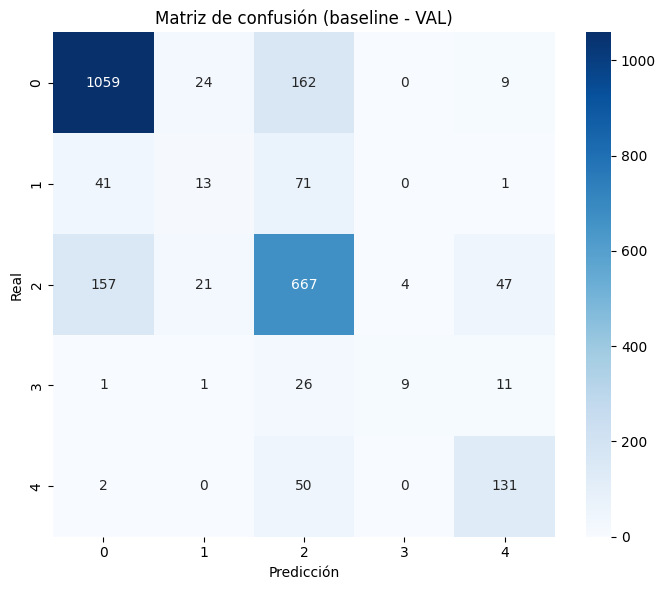

In [18]:
# 6) Matriz de confusión.
labels_sorted = sorted(int(x) for x in np.unique(y_val))
cm = confusion_matrix(y_val, y_pred, labels=labels_sorted)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels_sorted,
    yticklabels=labels_sorted,
)
plt.title("Matriz de confusión (baseline - VAL)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

## 11) Conclusiones y respuesta a las preguntas de la fase

### ¿Qué algoritmo usamos como baseline?

El baseline de referencia es **DenseNet-121 + XGBoost**. Conviene porque combina una extracción visual sólida con un clasificador rápido y estable para este nivel de datos.

### ¿Podemos determinar importancia de características?

Sí. XGBoost permite análisis embebido de importancia, lo cual ayuda a identificar señales más influyentes y reducir el impacto de variables irrelevantes.

### ¿Hay sobreajuste o subajuste?

La interpretación se hace con métricas globales y por clase. Si hay buena métrica global pero bajo desempeño en clases minoritarias, conviene reforzar revisión de generalización y balance de señal.

### ¿Qué métrica es adecuada para negocio?

Para este contexto conviene priorizar métricas que reflejen desempeño por clase, especialmente **macro-recall** y **macro-F1**, usando accuracy como referencia secundaria.

### ¿Cuál debe ser el desempeño mínimo?

El baseline debe superar claramente un predictor ingenuo de clase mayoritaria para considerar que el problema es viable con el pipeline actual.

Este baseline queda como referencia para las siguientes iteraciones del proyecto.


Referencias:

- Nneji, G. U., Cai, J., Deng, J., Monday, H. N., Hossin, M. A., & Nahar, S. (2022). Identification of diabetic retinopathy using weighted fusion deep learning based on dual-channel fundus scans. Diagnostics, 12(2), 540.
- Meenakshi, K., Kishore, D., & Srinivasa Rao, C. (2024, October). Enhanced Detection of Diabetic Retinopathy Through Transfer Learning with DenseNet-121 and XGBoost Classifier. In International Conference on Computer & Communication Technologies (pp. 409-419). Singapore: Springer Nature Singapore.
- Visengeriyeva, L., Kammer, A., Bär, I., Kniesz, A., y Plöd, M. (2023). CRISP-ML(Q). The ML Lifecycle Process. MLOps. INNOQ.